# Trace preparation

AES-HD: 100k EM traces from an unprotected AES-128 core (SASEBO-GII, Virtex-5).
Last-round leakage target:

$$Y = \mathrm{HW}\big(\mathrm{InvSbox}[ct_{15} \oplus k] \oplus ct_{11}\big)$$

This notebook computes HD labels, selects POIs by SNR, z-scores them, and writes
the HDF5 the C engine reads. It also fixes the information ceiling  (how much a
linear model can extract, which bounds what any classifier here can do).


In [1]:
import os, math
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

import sca

DATA_DIR = "../AES_HD_Dataset"
OUT_H5   = "../modulated_dataset/aes_hd_snn_ready.h5"
PLOT_DIR = "../modulated_dataset/plots"
NUM_POIS = 20
TEST_FRAC = 0.20
SEED = 42
TARGET_CT_HI, TARGET_CT_LO = 15, 11
KEY_HEX = "2b7e151628aed2a6abf7158809cf4f3c"
os.makedirs(PLOT_DIR, exist_ok=True)

## Last-round key and labels



In [2]:
RCON = [0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1b,0x36]

def last_round_key(key16):
    sbox = np.zeros(256, np.uint8)
    for i in range(256):
        sbox[sca.INV_SBOX[i]] = i
    words = [list(key16[i:i+4]) for i in range(0, 16, 4)]
    for rnd in range(1, 11):
        t = words[-1][1:] + words[-1][:1]
        t = [int(sbox[b]) for b in t]
        t[0] ^= RCON[rnd-1]
        words.append([words[-4][i] ^ t[i] for i in range(4)])
        for _ in range(3):
            words.append([words[-1][i] ^ words[-4][i] for i in range(4)])
    return np.array(sum(words[40:44], []), np.uint8)

def hd_labels(ct, k_hi, hi, lo):
    inner = sca.INV_SBOX[np.bitwise_xor(ct[:, hi], np.uint8(k_hi))]
    return sca.HW_LUT[np.bitwise_xor(inner, ct[:, lo])]

In [3]:
data = np.load(os.path.join(DATA_DIR, "aes_hd.npz"))["data"].astype(np.uint8)
ciphertext = data[:, 16:32]

key16 = np.frombuffer(bytes.fromhex(KEY_HEX), np.uint8)
last_rk = last_round_key(key16)
true_k = int(last_rk[TARGET_CT_HI])
print("last round key:", bytes(last_rk).hex())
print("true rk_last[%d] = %d" % (TARGET_CT_HI, true_k))

labels_all = hd_labels(ciphertext, true_k, TARGET_CT_HI, TARGET_CT_LO)

last round key: d014f9a8c9ee2589e13f0cc8b6630ca6
true rk_last[15] = 166


In [ ]:
npz = np.load(os.path.join(DATA_DIR, "aes_hd.npz"))
if "traces" in npz.files:
    traces_all = npz["traces"].astype(np.float32)
else:
    print("keys in npz:", npz.files)
    raise SystemExit("no 'traces' array in aes_hd.npz")

n = min(len(traces_all), len(labels_all), len(ciphertext))
traces_all, labels_all, ciphertext = traces_all[:n], labels_all[:n], ciphertext[:n]
print(f"{len(traces_all)} traces x {traces_all.shape[1]} samples")
print("class counts:", np.bincount(labels_all, minlength=9))

50000 traces x 1250 samples
class counts: [  206  1581  5484 10994 13710 10793  5477  1575   180]


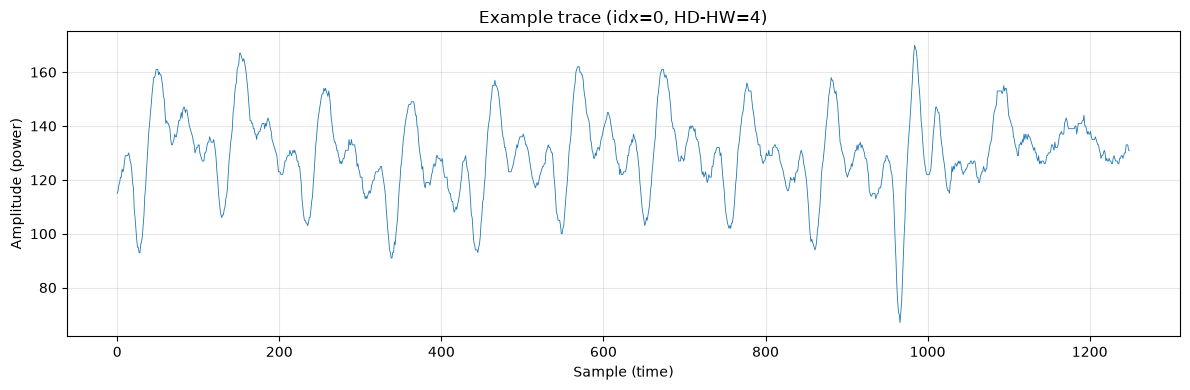

In [13]:
sample_trace = traces_all[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample_trace, lw=0.6)
ax.set_title(f"Example trace (idx=0, HD-HW={labels_all[0]})")
ax.set_xlabel("Sample (time)")
ax.set_ylabel("Amplitude (power)")
ax.grid(alpha=0.3)
fig.tight_layout()

plt.show()

fig.savefig(os.path.join(PLOT_DIR, "01_sample_trace.png"), dpi=120)
plt.close(fig)

## POI selection

SNR per sample is between-class mean variance over within-class variance. The 20
highest-SNR samples become the inputs. The HD distribution is binomial, so the
extreme classes (0, 8) are rare (relevant later for calibration).


In [5]:
num_classes, num_s = 9, traces_all.shape[1]
mean_pc = np.zeros((num_classes, num_s))
var_pc  = np.zeros((num_classes, num_s))
for c in range(num_classes):
    idx = labels_all == c
    if idx.any():
        mean_pc[c] = traces_all[idx].mean(0)
        var_pc[c]  = traces_all[idx].var(0)

snr = mean_pc.var(0) / (var_pc.mean(0) + 1e-9)
poi = np.sort(np.argsort(snr)[-NUM_POIS:])
print("POIs:", poi)
print(f"SNR range at POIs: {snr[poi].min():.4f} .. {snr[poi].max():.4f}")

poi_raw = traces_all[:, poi].astype(np.float64)
poi_mean, poi_std = poi_raw.mean(0), poi_raw.std(0) + 1e-9
poi_z = ((poi_raw - poi_mean) / poi_std).astype(np.float32)

POIs: [ 957  958  959  960  961  962  963  964  965  966  967  968  969  970
  971 1094 1095 1096 1100 1101]
SNR range at POIs: 0.0129 .. 0.0562


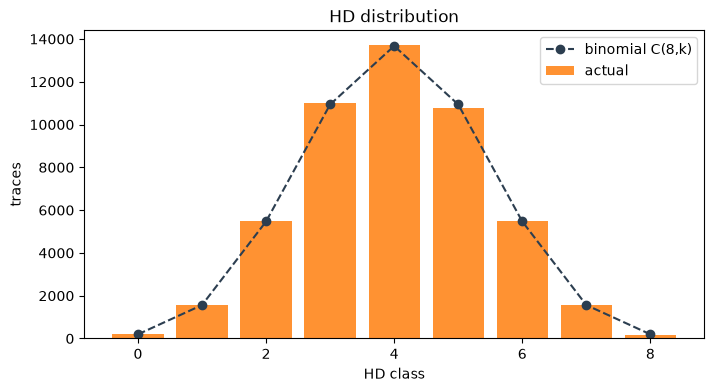

In [6]:
counts = np.bincount(labels_all, minlength=9)
binom = np.array([math.comb(8, k) for k in range(9)], float)
binom = binom / binom.sum() * counts.sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(9), counts, color="#ff7f0e", alpha=0.85, label="actual")
ax.plot(range(9), binom, "o--", color="#2c3e50", label="binomial C(8,k)")
ax.set_xlabel("HD class"); ax.set_ylabel("traces"); ax.legend()
ax.set_title("HD distribution")
fig.savefig(os.path.join(PLOT_DIR, "02_hw_distribution.png"), dpi=120)
plt.show()

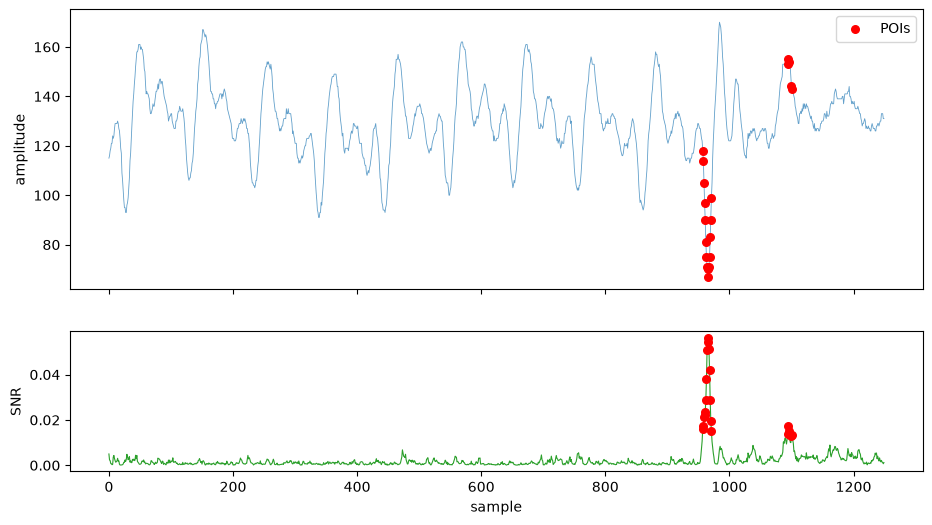

In [7]:
sample = traces_all[0]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                             gridspec_kw={"height_ratios":[2,1]})
a1.plot(sample, lw=0.6, color="#1f77b4", alpha=0.7)
a1.scatter(poi, sample[poi], color="red", s=30, zorder=5, label="POIs")
a1.set_ylabel("amplitude"); a1.legend()
a2.plot(snr, lw=0.8, color="#2ca02c")
a2.scatter(poi, snr[poi], color="red", s=30, zorder=5)
a2.set_xlabel("sample"); a2.set_ylabel("SNR")
fig.savefig(os.path.join(PLOT_DIR, "03_trace_with_pois.png"), dpi=120)
plt.show()

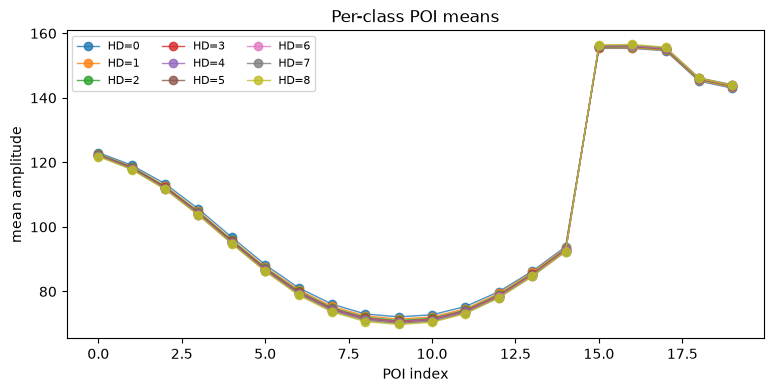

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for c in range(num_classes):
    ax.plot(mean_pc[c][poi], marker="o", lw=1, alpha=0.8, label=f"HD={c}")
ax.set_xlabel("POI index"); ax.set_ylabel("mean amplitude")
ax.set_title("Per-class POI means"); ax.legend(ncol=3, fontsize=8)
fig.savefig(os.path.join(PLOT_DIR, "04_poi_class_means.png"), dpi=120)
plt.show()

## Information ceiling

The class means nearly overlap, so the leakage is weak. The POI sweep bounds it:
logistic regression and random forest balanced accuracy against POI count. This
is the ceiling for the classifiers  (including the SNN).


In [9]:
rng = np.random.default_rng(SEED)
tr_parts, te_parts = [], []
for c in range(num_classes):
    ic = np.where(labels_all == c)[0]
    rng.shuffle(ic)
    cut = int(round(TEST_FRAC * len(ic)))
    te_parts.append(ic[:cut]); tr_parts.append(ic[cut:])
train_idx = np.sort(np.concatenate(tr_parts))
test_idx  = np.sort(np.concatenate(te_parts))

In [10]:
poi_counts = (10, 20, 50, 100, 200, 400)
lr_b, rf_b, used = [], [], []
for npoi in poi_counts:
    idx = np.sort(np.argsort(snr)[-npoi:])
    raw = traces_all[:, idx].astype(np.float64)
    mu, sd = raw[train_idx].mean(0), raw[train_idx].std(0) + 1e-9
    z = ((raw - mu) / sd).astype(np.float32)
    Xtr, Xte = z[train_idx], z[test_idx]
    ytr, yte = labels_all[train_idx], labels_all[test_idx]

    lr = LogisticRegression(max_iter=2000, C=0.1, class_weight="balanced").fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                n_jobs=-1, random_state=SEED).fit(Xtr, ytr)
    lr_b.append(balanced_accuracy_score(yte, lr.predict(Xte)))
    rf_b.append(balanced_accuracy_score(yte, rf.predict(Xte)))
    used.append(npoi)
    print(f"{npoi:>4} POIs   LR {lr_b[-1]:.4f}   RF {rf_b[-1]:.4f}")

  10 POIs   LR 0.1440   RF 0.1122
  20 POIs   LR 0.1399   RF 0.1157
  50 POIs   LR 0.1435   RF 0.1152
 100 POIs   LR 0.1438   RF 0.1171
 200 POIs   LR 0.1520   RF 0.1157
 400 POIs   LR 0.1518   RF 0.1145


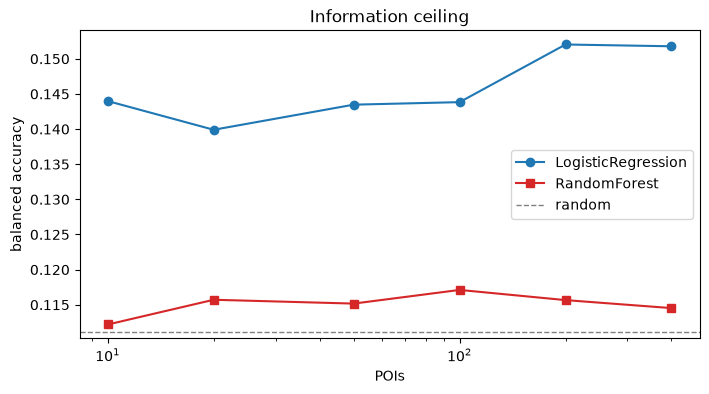

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(used, lr_b, "o-", color="#1f77b4", label="LogisticRegression")
ax.plot(used, rf_b, "s-", color="#d62728", label="RandomForest")
ax.axhline(1/9, color="gray", ls="--", lw=1, label="random")
ax.set_xscale("log"); ax.set_xlabel("POIs"); ax.set_ylabel("balanced accuracy")
ax.set_title("Information ceiling"); ax.legend()
fig.savefig(os.path.join(PLOT_DIR, "05_poi_sweep.png"), dpi=120)
plt.show()

## Write HDF5

Stratified split, z-score using profiling statistics, write the file the C
engine and the attack notebooks consume.


In [12]:
Xtr, ytr, cttr = poi_z[train_idx], labels_all[train_idx], ciphertext[train_idx]
Xte, yte, ctte = poi_z[test_idx],  labels_all[test_idx],  ciphertext[test_idx]

os.makedirs(os.path.dirname(OUT_H5), exist_ok=True)
with h5py.File(OUT_H5, "w") as f:
    g = f.create_group("Profiling_traces")
    g.create_dataset("traces", data=Xtr, compression="gzip")
    g.create_dataset("labels_hw", data=ytr.astype(np.uint8))
    g.create_dataset("ciphertext", data=cttr.astype(np.uint8), compression="gzip")
    g = f.create_group("Attack_traces")
    g.create_dataset("traces", data=Xte, compression="gzip")
    g.create_dataset("labels_hw", data=yte.astype(np.uint8))
    g.create_dataset("ciphertext", data=ctte.astype(np.uint8), compression="gzip")
    m = f.create_group("meta")
    m.create_dataset("poi_indices", data=poi.astype(np.int32))
    m.create_dataset("target_ct_hi", data=np.int32(TARGET_CT_HI))
    m.create_dataset("target_ct_lo", data=np.int32(TARGET_CT_LO))
    m.create_dataset("true_key_byte", data=np.int32(true_k))
print("wrote", OUT_H5)
print("train", len(Xtr), "| attack", len(Xte))

wrote ../modulated_dataset/aes_hd_snn_ready.h5
train 40000 | attack 10000
